# 🎓 Student Academic Performance Analysis: Predictive Modeling & Insights

---

 **📌 Project Overview** This project aims to predict student academic performance (`final_score`) and identify the key factors that influence their success. By using a robust **Machine Learning Pipeline**, the analysis explores how study habits, attendance, and background data contribute to a student's final results.

---

 **📊 Summary**

 **1. Model Performance & Stability** *To ensure the reliability of our predictions.*
- The model achieved an **R² Score of 0.80**, meaning it can explain 80% of the variation in student scores. 
- Cross-validation results confirmed the model's stability with an average **MAE of 5.54**, indicating that on average, our predictions only deviate by about 5-6 points from the actual scores.

 **2. The Power of Personal Effort** *To identify the most influential success factors.*
- **Study Hours per Week** is the strongest predictor of success (**Weight: 8.89**). This confirms that time investment is the primary driver of high scores.
- **Attendance Rate** (**Weight: 3.12**) also plays a crucial role, showing that being present in class consistently leads to better academic outcomes.

 **3. Academic History & Continuity** *To understand the impact of past performance.*
- Students with a history of passing (**Passed_Yes**) show much higher performance (**Weight: 5.57**). 
- Conversely, a history of failing (**Passed_No**) is the strongest negative indicator (**Weight: -5.57**), suggesting that students in this group need early intervention and extra support.

 **4. Environmental vs. Behavioral Factors** *To see if background matters as much as behavior.*
- Factors like **Gender**, **Internet Access**, and **Parent Education** have near-zero impact on the final score in this dataset. 
- This highlights a key finding: **Behavioral habits** (studying and attending class) are far more critical to success than a student's socio-economic or demographic background.

---

 **🛠 Technical Highlights**
- **Preprocessing Pipeline**: Implemented `PowerTransformer (Yeo-Johnson)` to handle skewed data and `StandardScaler` to balance feature scales.
- **Advanced Encoding**: Used `OrdinalEncoder` for ranked education data and `OneHotEncoder` for categorical variables.
- **Model Diagnostics**: Analyzed model coefficients and verified model performance using **5-Fold Cross-Validation**.

---

 **📚 Data Source**
- **Dataset**: Student Academic Performance (500 Students)
- **Source**: [Kaggle - Student Academic Performance Dataset](https://www.kaggle.com/datasets/mubashirsidiki/student-academic-performance-500-students)

# Setup Environment

In [1]:
%pip install git+https://github.com/Sakda-Phoda/papa_tools.git
import kagglehub
from kagglehub import KaggleDatasetAdapter as kda
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import PowerTransformer, StandardScaler
from papa.vis import vis_corr
import warnings
warnings.filterwarnings('ignore')

def  num_fmt(x, pos=None):
    sign = '-' if x < 0 else ''
    x = abs(float(x))
    if x >= 1_000_000:
        return f'{sign}{x / 1_000_000:.1f}M'
    if x >= 1_000:
        return f'{sign}{x / 1_000:.0f}K'
    return f'{sign}{x:,.0f}'


  Cloning https://github.com/Sakda-Phoda/papa_tools.git to C:\Users\xmn3p\AppData\Local\Temp\pip-req-build-cv8y0see
  Resolved https://github.com/Sakda-Phoda/papa_tools.git to commit f9e0a10426af5d8bde47c2d1d105e3575437a487
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Note: you may need to restart the kernel to use updated packages.


  Running command git clone --filter=blob:none --quiet https://github.com/Sakda-Phoda/papa_tools.git 'C:\Users\xmn3p\AppData\Local\Temp\pip-req-build-cv8y0see'
c:\Users\xmn3p\miniconda3\envs\ds_2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load and Clean Data

In [2]:
df = kagglehub.dataset_load(
    kda.PANDAS
    , 'mubashirsidiki/student-academic-performance-500-students'
    , 'student_performance.csv'
)

df.columns = df.columns.str.lower().str.strip().str.strip()
df.head()


,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes


In [3]:
df = df.drop('student_id',axis=1)
df.info() # Check Data Type


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender                500 non-null    str    
 1   age                   500 non-null    int64  
 2   study_hours_per_week  500 non-null    int64  
 3   attendance_rate       500 non-null    float64
 4   parent_education      383 non-null    str    
 5   internet_access       500 non-null    str    
 6   extracurricular       500 non-null    str    
 7   previous_score        500 non-null    int64  
 8   final_score           500 non-null    int64  
 9   passed                500 non-null    str    
dtypes: float64(1), int64(4), str(5)
memory usage: 39.2 KB


In [4]:
df.isna().sum() # Check Null


gender                    0
age                       0
study_hours_per_week      0
attendance_rate           0
parent_education        117
internet_access           0
extracurricular           0
previous_score            0
final_score               0
passed                    0
dtype: int64

In [5]:
df['parent_education'].unique()


<StringArray>
['Bachelor', 'High School', 'Master', nan, 'PhD']
Length: 5, dtype: str

จากข้อมูลใน column parent_education จะมีอยู่หลายระดับการศึกษา แต่ยังขาดประเภทที่ไม่ได้รับการศึกษา ดังนั้นจึงเติมข้อมูลที่ขาดหลายด้วย No Degree

In [6]:
df['parent_education'] = df['parent_education'].fillna('No Degree')
df['parent_education'].unique()


<StringArray>
['Bachelor', 'High School', 'Master', 'No Degree', 'PhD']
Length: 5, dtype: str

Coefficient of Determination (R²): 0.8283


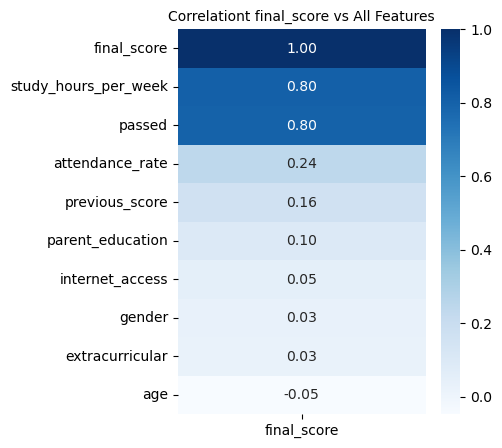

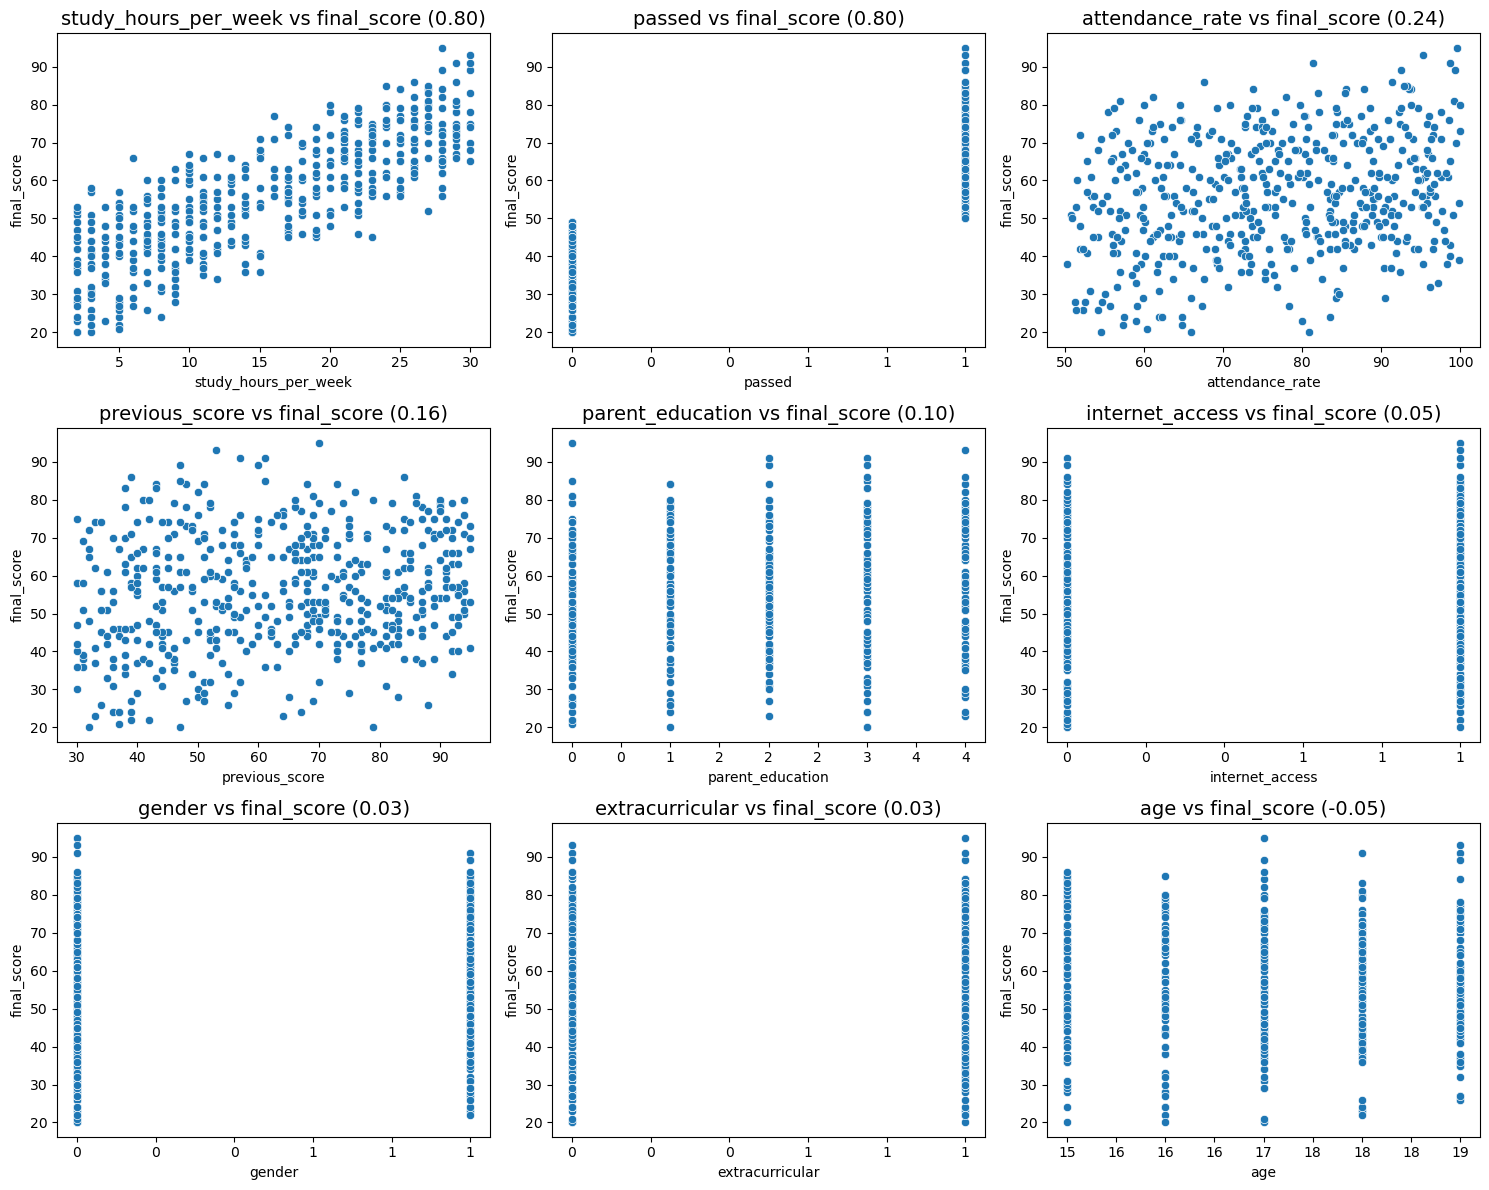

In [7]:
vis_corr(df,'final_score')


In [8]:
x = df.drop('final_score',axis=1)
y = df['final_score']

x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=1)

ord_feature = ['parent_education']
nom_feature = ['gender','internet_access','extracurricular','passed']

# pipeline number feature (parent_education)
num_pipe = Pipeline([
    ('yj', PowerTransformer(method='yeo-johnson'))
    , ('scaler', StandardScaler())
])

# pipeline ordinal feature (parent_education)
ord_pipe = Pipeline([
    ('ordinal', OrdinalEncoder(categories=[['No Degree','High School','Bachelor','Master','PhD']]))
    , ('yj', PowerTransformer(method='yeo-johnson'))
    , ('scaler', StandardScaler())
])

# Create Column Transform Step
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, make_column_selector(dtype_include= np.number))
    , ('ord', ord_pipe, ord_feature)
    , ('nom', OneHotEncoder(handle_unknown='ignore'), nom_feature)
])

pipe = Pipeline([
    ('preprocessor', preprocessor)
    , ('model', LinearRegression())
])

# Fit Model and Predict
pipe.fit(x_train, y_train)
y_pred = pipe.predict(x_test)

# Evaluate Model
scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error',
    'rmse': 'neg_root_mean_squared_error'
}

cv_result = cross_validate(pipe, x_train, y_train, cv=5, scoring=scoring)

cv_result_df = pd.DataFrame(cv_result).drop(['fit_time','score_time'],axis=1).round(2)
cv_result_df['test_mae'] = -cv_result_df['test_mae']
cv_result_df['test_mse'] = -cv_result_df['test_mse']
cv_result_df['test_rmse'] = -cv_result_df['test_rmse']

print(f"📊 Cross-Validation (Avg Results):")
print(f"{'='*30}")
print(f"R²:   {cv_result_df['test_r2'].mean():.2f}")
print(f"MAE:  {cv_result_df['test_mae'].mean():.2f}")
print(f"MSE:  {cv_result_df['test_mse'].mean():.2f}")
print(f"RMSE: {cv_result_df['test_rmse'].mean():.2f}")

cv_result_df


📊 Cross-Validation (Avg Results):
R²:   0.80
MAE:  5.54
MSE:  45.18
RMSE: 6.72


,test_r2,test_mae,test_mse,test_rmse
0,0.78,5.34,42.86,6.55
1,0.83,5.02,42.74,6.54
2,0.82,5.79,45.68,6.76
3,0.79,5.58,44.42,6.66
4,0.77,5.99,50.22,7.09


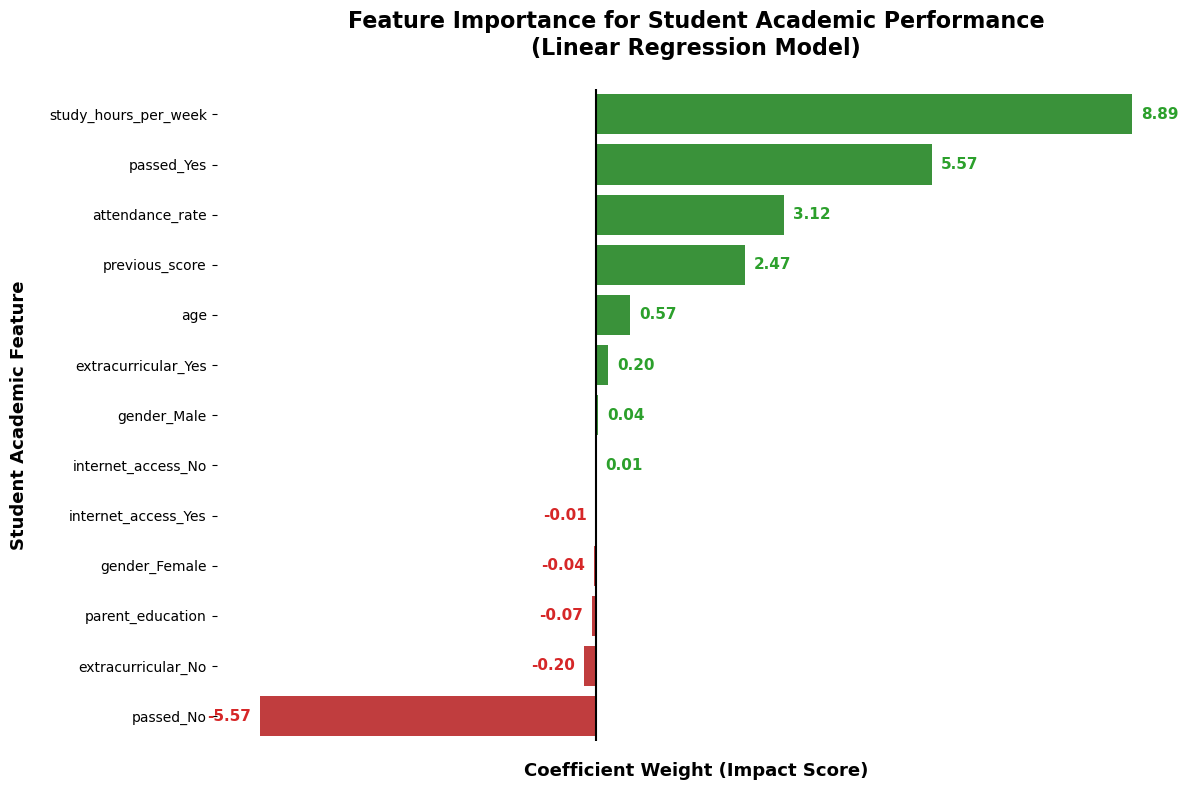

In [ ]:
# Feature Importance
feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()
coeffs = pipe.named_steps['model'].coef_
importance_df = pd.DataFrame({
    'feature_full': feature_names,
    'weight': coeffs
})
importance_df['feature_clean'] = importance_df['feature_full'].str.split('__').str[-1]
importance_df = importance_df.sort_values(by='weight', ascending=False)

# Visualize
importance_df['color'] = np.where(importance_df['weight'] > 0, 'positive', 'negative')
color_palette = {'positive': 'tab:green', 'negative': 'tab:red'}

fig, ax = plt.subplots(figsize=(12, 8))

bar_plot = sns.barplot(
    data=importance_df
    , x='weight'
    , y='feature_clean'
    , hue='color'
    , palette=color_palette
    , legend=False
)

ax.axvline(x=0, color='black', linestyle='-')

for p in bar_plot.patches:
    width = p.get_width()
    x_pos = width + 0.15 if width > 0 else width - 0.15
    y_pos = p.get_y() + p.get_height() / 2
    color = 'tab:green' if width > 0 else 'tab:red'
    ax.text(x_pos, y_pos, f'{width:.2f}'
            , va='center'
            , ha='left' if width > 0 else 'right'
            , color=color
            , fontsize=11, fontweight='bold')

plt.xlabel('Coefficient Weight (Impact Score)', fontsize=13, fontweight='bold', labelpad=15)
plt.ylabel('Student Academic Feature', fontsize=13, fontweight='bold', labelpad=15)
plt.title('Feature Importance for Student Academic Performance\n(Linear Regression Model)', 
          fontsize=16, fontweight='bold', pad=25)

sns.despine(left=True, bottom=True)
ax.set_xticks([])

plt.tight_layout()
plt.show()


**Top Positive Factors (Key Drivers)**
- **Study Hours per Week**: This is the most important factor (Weight = 8.89). It clearly shows that the more time students spend studying, the higher their exam scores will be.
- **Previously Passed (Passed_Yes)**: Students who have a history of passing exams tend to perform better than others (Weight = 5.57).
- **Attendance Rate & Previous Score**: Both are important supporting factors. This means that attending class regularly and having a good basic knowledge always lead to better results.

**Negative Factors (Negative Impact)**
- **Previously Failed (Passed_No)**: This is the strongest negative sign (Weight = -5.57). Students in this group are likely to struggle more with their scores.
- **No Extracurricular Activities**: Not joining any activities has a slight negative effect (-0.20) compared to students who participate in them.

**Factors with Little to No Effect (Neutral Factors)**
- **Gender, Internet Access, and Parent Education**: These factors have weights very close to 0. This suggests that in this dataset, a student's background and environment matter much less than their personal effort, such as study hours and class attendance.